<a href="https://colab.research.google.com/github/tedeliott/multi_opti_for_GoldNPs/blob/main/research_project_round_1_chip.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Multi optimization for gold nanoparticles

## 1. Dataset

import raw dataset

In [29]:
import pandas as pd
import numpy as np

data = [
    # Sample_ID, inner_index, Date, HAuCl4_mM, PVP_mg_ml, AA_mM, Citrate_mM, pH,
    # Au_flow_rate, reducing_agent_flow_rate_mL_h, Z_Average_nm, PDI, Zeta_mV, note

    ["AuNP_001", "A", "07/07/2026", 1, 10, 20, 0,   3, 30, 30, 118.7,  0.1187, -5.33433,  "raw data"],
    ["AuNP_002", "B", "07/07/2026", 1, 10, 20, 0,  11, 30, 30, 60.93,  0.9589, -3.77667,  "raw data"],
    ["AuNP_003", "C", "07/07/2026", 1, 0,  20, 0,   3, 30, 30, 67.94,  0.2034, -18.96,    "raw data"],
    ["AuNP_004", "D", "07/07/2026", 1, 0,  20, 0,  11, 30, 30, 40.38,  0.4956, -30.5333,  "raw data"],
    ["AuNP_005", "E", "07/07/2026", 1, 5,  20, 0,   3, 30, 30, 119.8,  0.1232, -5.98233,  "raw data"],
    ["AuNP_006", "F", "07/07/2026", 1, 5,  20, 2,   3, 30, 30, 104.4,  0.1955, -5.02267,  "raw data"],
    ["AuNP_007", "G", "07/07/2026", 1, 5,  20, 0.2, 3, 30, 30, 120.5,  0.1305, -6.61533,  "raw data"],
]

columns = [
    "Sample_ID",
    "inner_index",
    "Date",
    "HAuCl4_mM",
    "PVP_mg_ml",
    "AA_mM",
    "Citrate_mM",
    "pH",
    "Au_flow_rate",
    "reducing_agent_flow_rate_mL_h",
    "Z_Average_nm",
    "PDI",
    "Zeta_mV",
    "note"
]

df_raw = pd.DataFrame(data, columns=columns)

df_raw["Date"] = pd.to_datetime(df_raw["Date"], dayfirst=True)

df_raw

,Sample_ID,inner_index,Date,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,Z_Average_nm,PDI,Zeta_mV,note
0,AuNP_001,A,2026-07-07,1,10,20,0.0,3,30,30,118.70,0.1187,-5.33433,raw data
1,AuNP_002,B,2026-07-07,1,10,20,0.0,11,30,30,60.93,0.9589,-3.77667,raw data
2,AuNP_003,C,2026-07-07,1,0,20,0.0,3,30,30,67.94,0.2034,-18.96000,raw data
3,AuNP_004,D,2026-07-07,1,0,20,0.0,11,30,30,40.38,0.4956,-30.53330,raw data
4,AuNP_005,E,2026-07-07,1,5,20,0.0,3,30,30,119.80,0.1232,-5.98233,raw data
5,AuNP_006,F,2026-07-07,1,5,20,2.0,3,30,30,104.40,0.1955,-5.02267,raw data
6,AuNP_007,G,2026-07-07,1,5,20,0.2,3,30,30,120.50,0.1305,-6.61533,raw data


delete ineffective data(e.g. very slow data)

In [31]:
df_model = df_raw.dropna(subset=["Z_Average_nm", "PDI", "Zeta_mV"]).copy()

df_model

,Sample_ID,inner_index,Date,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,Z_Average_nm,PDI,Zeta_mV,note
0,AuNP_001,A,2026-07-07,1,10,20,0.0,3,30,30,118.70,0.1187,-5.33433,raw data
1,AuNP_002,B,2026-07-07,1,10,20,0.0,11,30,30,60.93,0.9589,-3.77667,raw data
2,AuNP_003,C,2026-07-07,1,0,20,0.0,3,30,30,67.94,0.2034,-18.96000,raw data
3,AuNP_004,D,2026-07-07,1,0,20,0.0,11,30,30,40.38,0.4956,-30.53330,raw data
4,AuNP_005,E,2026-07-07,1,5,20,0.0,3,30,30,119.80,0.1232,-5.98233,raw data
5,AuNP_006,F,2026-07-07,1,5,20,2.0,3,30,30,104.40,0.1955,-5.02267,raw data
6,AuNP_007,G,2026-07-07,1,5,20,0.2,3,30,30,120.50,0.1305,-6.61533,raw data


input variable X

In [32]:
input_cols = [
    "HAuCl4_mM",
    "PVP_mg_ml",
    "AA_mM",
    "Citrate_mM",
    "pH",
    "Au_flow_rate",
    "reducing_agent_flow_rate_mL_h"
]

X = df_model[input_cols].values

X

array([[ 1. , 10. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. , 10. , 20. ,  0. , 11. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. ,  0. , 20. ,  0. , 11. , 30. , 30. ],
       [ 1. ,  5. , 20. ,  0. ,  3. , 30. , 30. ],
       [ 1. ,  5. , 20. ,  2. ,  3. , 30. , 30. ],
       [ 1. ,  5. , 20. ,  0.2,  3. , 30. , 30. ]])

adjusting objectives

set the dpi=0.2, first time i do not set the target cause the dpi is varing, the ai-guided experiments are so good in dpi so i dissmiss the dpi target

In [33]:
pdi_target = 0.2

df_model["pdi_penalty"] = np.maximum(df_model["PDI"] - pdi_target, 0)
df_model["abs_zeta"] = abs(df_model["Zeta_mV"])


In [34]:


objective_cols = [
    "pdi_penalty",
     "abs_zeta"
]

Y_objectives = df_model[objective_cols].values

Y_objectives

array([[0.00000e+00, 5.33433e+00],
       [7.58900e-01, 3.77667e+00],
       [3.40000e-03, 1.89600e+01],
       [2.95600e-01, 3.05333e+01],
       [0.00000e+00, 5.98233e+00],
       [0.00000e+00, 5.02267e+00],
       [0.00000e+00, 6.61533e+00]])

## 2. Establish single scalarizing function with **Chimera**

In [35]:
pip install matter-chimera

In [36]:
from chimera import Chimera

chimera = Chimera(
    tolerances=[0.2, 0.1],
    absolutes=[False, False],
    goals=["min", "max"]
)

y_chimera = chimera.scalarize(Y_objectives)

df_model["chimera_merit"] = y_chimera

df_model[[
    "Sample_ID",
    "PDI",
    "Z_Average_nm",
    "Zeta_mV",
    "abs_zeta",
    "pdi_penalty",
    "chimera_merit"
]]

,Sample_ID,PDI,Z_Average_nm,Zeta_mV,abs_zeta,pdi_penalty,chimera_merit
0,AuNP_001,0.1187,118.70,-5.33433,5.33433,0.0000,0.360304
1,AuNP_002,0.9589,60.93,-3.77667,3.77667,0.7589,1.000000
2,AuNP_003,0.2034,67.94,-18.96000,18.96000,0.0034,0.000000
3,AuNP_004,0.4956,40.38,-30.53330,30.53330,0.2956,0.518847
4,AuNP_005,0.1232,119.80,-5.98233,5.98233,0.0000,0.341217
5,AuNP_006,0.1955,104.40,-5.02267,5.02267,0.0000,0.369485
6,AuNP_007,0.1305,120.50,-6.61533,6.61533,0.0000,0.322571


## 3. Model

process 1: investigating trends

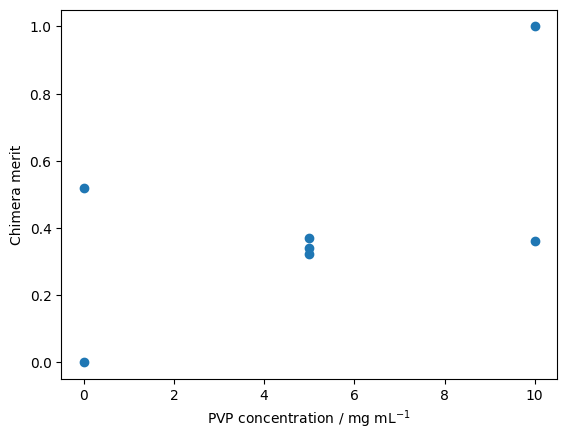

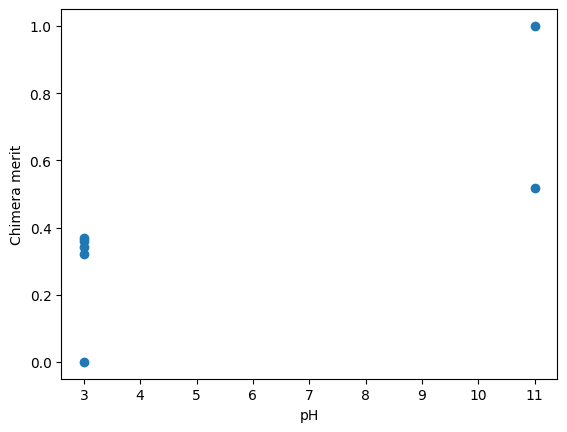

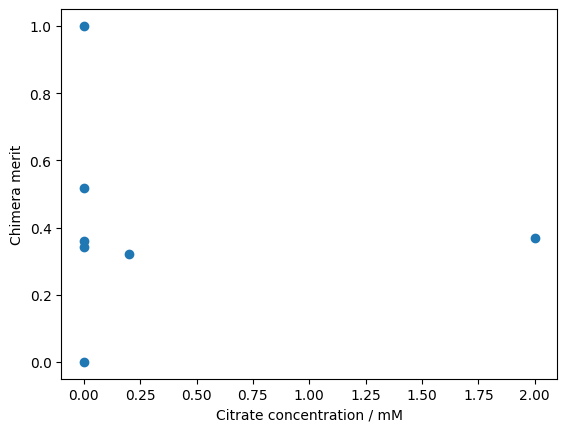

In [37]:
import matplotlib.pyplot as plt

plt.scatter(df_model["PVP_mg_ml"], df_model["chimera_merit"])
plt.xlabel("PVP concentration / mg mL$^{-1}$")
plt.ylabel("Chimera merit")
plt.show()

plt.scatter(df_model["pH"], df_model["chimera_merit"])
plt.xlabel("pH")
plt.ylabel("Chimera merit")
plt.show()

plt.scatter(df_model["Citrate_mM"], df_model["chimera_merit"])
plt.xlabel("Citrate concentration / mM")
plt.ylabel("Chimera merit")
plt.show()

process 2: surrogate model

In [38]:
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import Matern, WhiteKernel, ConstantKernel
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline

y = df_model["chimera_merit"].values

kernel = ConstantKernel(1.0) * Matern(nu=2.5) + WhiteKernel()

gp = make_pipeline(
    StandardScaler(),
    GaussianProcessRegressor(kernel=kernel, normalize_y=True, random_state=0)
)

gp.fit(X, y)

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified lower bound 1e-05. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(


Pipeline(steps=[('standardscaler', StandardScaler()),
                ('gaussianprocessregressor',
                 GaussianProcessRegressor(kernel=1**2 * Matern(length_scale=1, nu=2.5) + WhiteKernel(noise_level=1),
                                          normalize_y=True, random_state=0))])

In [39]:
from scipy.stats import norm

In [40]:
def expected_improvement_minimization(X_candidates, gp, y_observed, xi=0.01):
    """
    Expected Improvement for minimization.

    X_candidates: candidate experimental conditions
    gp: trained Gaussian Process pipeline
    y_observed: observed Chimera merit values
    xi: exploration parameter
    """

    mu, sigma = gp.predict(X_candidates, return_std=True)

    y_best = np.min(y_observed)

    improvement = y_best - mu - xi

    Z = improvement / sigma

    ei = improvement * norm.cdf(Z) + sigma * norm.pdf(Z)

    ei[sigma == 0.0] = 0.0

    return ei, mu, sigma

In [44]:
candidate_data = []

for pvp in [ 0,1, 5, 10, 20, 30, 40, 50]:
    for citrate in [0, 0.1, 0.2, 0.5, 1, 2]:
        for ph in [3,4, 5,6, 7,8,9, 10, 11]:
            candidate_data.append([
                1,       # HAuCl4_mM
                pvp,     # PVP_mg_ml
                20,      # AA_mM
                citrate, # Citrate_mM
                ph,      # pH
                30,      # Au_flow_rate
                30       # reducing_agent_flow_rate_mL_h
            ])

X_candidates = np.array(candidate_data)
candidate_df = pd.DataFrame(X_candidates, columns=input_cols)

In [45]:
ei, mu, sigma = expected_improvement_minimization(
    X_candidates,
    gp,
    y,
    xi=0.01
)

candidate_df["predicted_merit_mu"] = mu
candidate_df["uncertainty_sigma"] = sigma
candidate_df["EI"] = ei

candidate_df.sort_values("EI", ascending=False).head(10)

,HAuCl4_mM,PVP_mg_ml,AA_mM,Citrate_mM,pH,Au_flow_rate,reducing_agent_flow_rate_mL_h,predicted_merit_mu,uncertainty_sigma,EI
27,1.0,0.0,20.0,0.5,3.0,30.0,30.0,0.034823,0.125666,0.030878
36,1.0,0.0,20.0,1.0,3.0,30.0,30.0,0.135183,0.203106,0.028298
37,1.0,0.0,20.0,1.0,4.0,30.0,30.0,0.161082,0.205627,0.023354
28,1.0,0.0,20.0,0.5,4.0,30.0,30.0,0.069526,0.133219,0.022582
38,1.0,0.0,20.0,1.0,5.0,30.0,30.0,0.197949,0.213098,0.018586
90,1.0,1.0,20.0,1.0,3.0,30.0,30.0,0.161906,0.185767,0.017805
18,1.0,0.0,20.0,0.2,3.0,30.0,30.0,0.000825,0.054925,0.016924
423,1.0,50.0,20.0,2.0,3.0,30.0,30.0,0.416079,0.336580,0.016469
424,1.0,50.0,20.0,2.0,4.0,30.0,30.0,0.416084,0.336580,0.016468
414,1.0,50.0,20.0,1.0,3.0,30.0,30.0,0.416085,0.336580,0.016468
